In [2]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [4]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.shape

(891, 15)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [7]:
df2 = df[['survived','pclass','age','parch']]
df2.head()

,survived,pclass,age,parch
0,0,3,22.0,0
1,1,1,38.0,0
2,1,3,26.0,0
3,1,1,35.0,0
4,0,3,35.0,0


In [8]:
df2.isnull().sum()

survived      0
pclass        0
age         177
parch         0
dtype: int64

In [9]:
df2['age'].mean()

np.float64(29.69911764705882)

In [10]:
df2.describe()

,survived,pclass,age,parch
count,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,29.699118,0.381594
std,0.486592,0.836071,14.526497,0.806057
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,20.125000,0.000000
50%,0.000000,3.000000,28.000000,0.000000
75%,1.000000,3.000000,38.000000,0.000000
max,1.000000,3.000000,80.000000,6.000000


In [11]:
df_fill = df2.fillna(df2.mean())

In [13]:
x = df_fill.drop('survived',axis = 1)
y = df_fill['survived']

In [15]:
print('Shape of X = ', x.shape)
print('Shape of Y = ', y.shape)

Shape of X =  (891, 3)
Shape of Y =  (891,)


## Train test

In [16]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

In [19]:
print('Shape of X_train = ', X_train.shape)
print('Shape of y_train = ', y_train.shape)
print('Shape of X_test = ', X_test.shape)
print('Shape of y_test = ', y_test.shape)

Shape of X_train =  (712, 3)
Shape of y_train =  (712,)
Shape of X_test =  (179, 3)
Shape of y_test =  (179,)


In [20]:
sc = StandardScaler()
sc.fit(X_train)

StandardScaler()

In [21]:
sc.mean_

array([ 2.33005618, 29.53822538,  0.37921348])

In [22]:
sc.scale_

array([ 0.82400502, 12.98541943,  0.79111317])

In [23]:
X_train.describe()

,pclass,age,parch
count,712.000000,712.000000,712.000000
mean,2.330056,29.538225,0.379213
std,0.824584,12.994548,0.791669
min,1.000000,0.420000,0.000000
25%,2.000000,22.000000,0.000000
50%,3.000000,29.699118,0.000000
75%,3.000000,35.000000,0.000000
max,3.000000,80.000000,6.000000


In [24]:
sc.transform(X_train)

array([[-1.61413602,  1.22920747, -0.47934164],
       [-0.40055118, -0.50350514, -0.47934164],
       [ 0.81303367,  0.18957991, -0.47934164],
       ...,
       [ 0.81303367,  0.88266495, -0.47934164],
       [-1.61413602, -1.19659018,  2.04874166],
       [-1.61413602, -0.65752403,  0.78470001]], shape=(712, 3))

In [25]:
X_train_sc = sc.transform(X_train)

In [26]:
X_train_sc

array([[-1.61413602,  1.22920747, -0.47934164],
       [-0.40055118, -0.50350514, -0.47934164],
       [ 0.81303367,  0.18957991, -0.47934164],
       ...,
       [ 0.81303367,  0.88266495, -0.47934164],
       [-1.61413602, -1.19659018,  2.04874166],
       [-1.61413602, -0.65752403,  0.78470001]], shape=(712, 3))

In [27]:
sc.transform(X_test)

array([[ 0.81303367,  0.01239022,  0.78470001],
       [-0.40055118,  0.11257046, -0.47934164],
       [ 0.81303367, -0.73453348, -0.47934164],
       [-0.40055118, -1.81266577,  0.78470001],
       [ 0.81303367, -1.19659018, -0.47934164],
       [-1.61413602, -0.27247679, -0.47934164],
       [ 0.81303367,  0.01239022, -0.47934164],
       [ 0.81303367, -1.04257128, -0.47934164],
       [ 0.81303367, -1.04257128, -0.47934164],
       [-1.61413602, -0.81154293,  2.04874166],
       [-1.61413602,  0.57462715, -0.47934164],
       [ 0.81303367,  1.1136933 , -0.47934164],
       [ 0.81303367,  0.01239022,  0.78470001],
       [ 0.81303367,  0.03556101, -0.47934164],
       [-0.40055118,  0.49761771, -0.47934164],
       [-1.61413602, -1.04257128,  0.78470001],
       [-1.61413602,  0.9596744 , -0.47934164],
       [ 0.81303367,  0.01239022, -0.47934164],
       [-0.40055118, -0.19546734, -0.47934164],
       [-1.61413602,  1.34472165, -0.47934164],
       [ 0.81303367, -0.42649569, -0.479

In [28]:
X_train

,pclass,age,parch
331,1,45.500000,0
733,2,23.000000,0
382,3,32.000000,0
704,3,26.000000,0
813,3,6.000000,2
...,...,...,...
106,3,21.000000,0
270,1,29.699118,0
860,3,41.000000,0
435,1,14.000000,2


In [31]:
X_train_sc = pd.DataFrame(X_train_sc, columns = ['pclass','age','parch'])

In [32]:
X_train_sc

,pclass,age,parch
0,-1.614136,1.229207,-0.479342
1,-0.400551,-0.503505,-0.479342
2,0.813034,0.189580,-0.479342
3,0.813034,-0.272477,-0.479342
4,0.813034,-1.812666,2.048742
...,...,...,...
707,0.813034,-0.657524,-0.479342
708,-1.614136,0.012390,-0.479342
709,0.813034,0.882665,-0.479342
710,-1.614136,-1.196590,2.048742


In [33]:
X_train_sc.describe()

,pclass,age,parch
count,7.120000e+02,7.120000e+02,7.120000e+02
mean,9.355812e-17,1.122697e-17,2.245395e-17
std,1.000703e+00,1.000703e+00,1.000703e+00
min,-1.614136e+00,-2.242379e+00,-4.793416e-01
25%,-4.005512e-01,-5.805146e-01,-4.793416e-01
50%,8.130337e-01,1.239022e-02,-4.793416e-01
75%,8.130337e-01,4.206083e-01,-4.793416e-01
max,8.130337e-01,3.886033e+00,7.104908e+00


In [34]:
X_train_sc.describe().round(2)

,pclass,age,parch
count,712.00,712.00,712.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.61,-2.24,-0.48
25%,-0.40,-0.58,-0.48
50%,0.81,0.01,-0.48
75%,0.81,0.42,-0.48
max,0.81,3.89,7.10


## MinMaxScaler

In [35]:
mns = MinMaxScaler()
mns.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](3,)","[ 3.,80., 6.]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](3,)","[1. ,0.42,0. ]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](3,)","[ 2. ,79.58, 6. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['pclass','age','parch']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](3,)","[-0.5 ,-0.01, 0. ]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,712


In [37]:
mns.scale_

array([0.5       , 0.01256597, 0.16666667])

In [39]:
X_train.describe()

,pclass,age,parch
count,712.000000,712.000000,712.000000
mean,2.330056,29.538225,0.379213
std,0.824584,12.994548,0.791669
min,1.000000,0.420000,0.000000
25%,2.000000,22.000000,0.000000
50%,3.000000,29.699118,0.000000
75%,3.000000,35.000000,0.000000
max,3.000000,80.000000,6.000000


In [40]:
X_train_mns = mns.transform(X_train)

In [41]:
X_train_mns

array([[0.        , 0.56647399, 0.        ],
       [0.5       , 0.28373963, 0.        ],
       [1.        , 0.39683338, 0.        ],
       ...,
       [1.        , 0.50992712, 0.        ],
       [0.        , 0.17064589, 0.33333333],
       [0.        , 0.25860769, 0.16666667]], shape=(712, 3))

In [43]:
X_test_mns = mns.transform(X_test)

In [44]:
X_test_mns

array([[1.        , 0.36792055, 0.16666667],
       [0.5       , 0.3842674 , 0.        ],
       [1.        , 0.24604172, 0.        ],
       [0.5       , 0.07011812, 0.16666667],
       [1.        , 0.17064589, 0.        ],
       [0.        , 0.32143755, 0.        ],
       [1.        , 0.36792055, 0.        ],
       [1.        , 0.19577783, 0.        ],
       [1.        , 0.19577783, 0.        ],
       [0.        , 0.23347575, 0.33333333],
       [0.        , 0.45966323, 0.        ],
       [1.        , 0.54762503, 0.        ],
       [1.        , 0.36792055, 0.16666667],
       [1.        , 0.37170143, 0.        ],
       [0.5       , 0.44709726, 0.        ],
       [0.        , 0.19577783, 0.16666667],
       [0.        , 0.52249309, 0.        ],
       [1.        , 0.36792055, 0.        ],
       [0.5       , 0.33400352, 0.        ],
       [0.        , 0.58532295, 0.        ],
       [1.        , 0.2963056 , 0.        ],
       [0.        , 0.42196532, 0.        ],
       [1.

In [45]:
X_train_mns = pd.DataFrame(X_train_mns, columns = ['pclass','age','parch'])

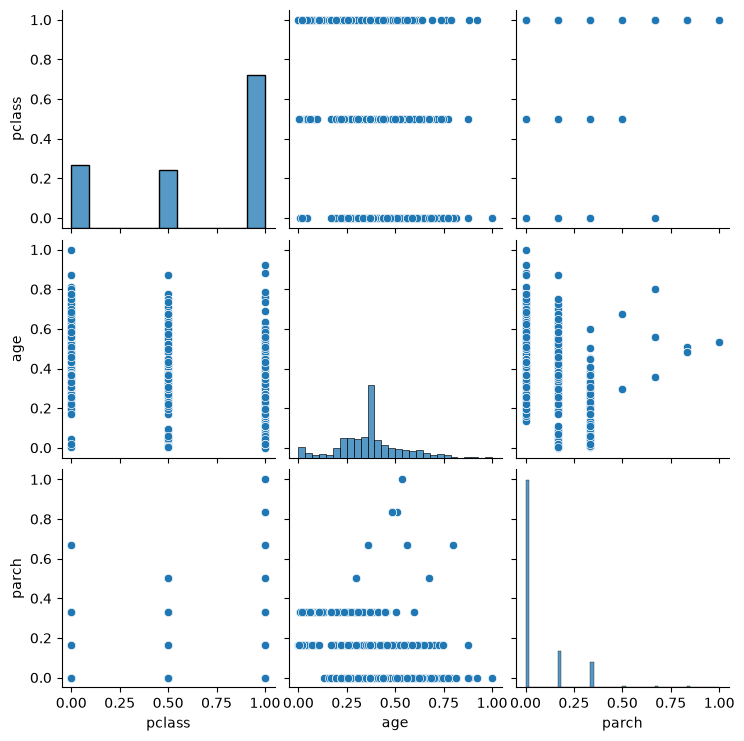

In [46]:
sns.pairplot(X_train_mns)

In [48]:
X_test_mns = pd.DataFrame(X_test_mns, columns = ['pclass','age','parch'])

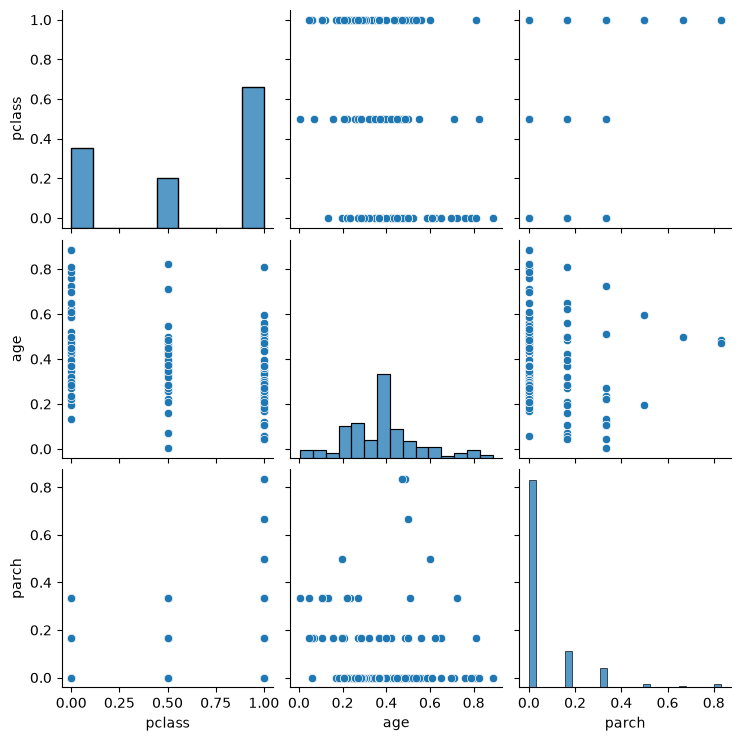

In [49]:
sns.pairplot(X_test_mns)